# Data Quality Audit

## Objective

This notebook performs a data quality audit on the raw employee dataset to verify completeness, identify duplicate records, assess data type correctness, detect constant features, run logical consistency sanity checks, and examine the target class distribution. The output of this audit determines if any cleaning is required before proceeding to exploratory analysis.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.plot_config import *

In [3]:
df = pd.read_csv("../data/raw/Employee_Data.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.sample(5, random_state=42)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,...,4,80,0,6,4,3,5,4,1,3
184,53,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,...,3,80,2,5,3,3,4,2,1,3
1222,24,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,...,3,80,1,1,2,3,1,0,0,0
67,45,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,...,3,80,1,25,2,3,1,0,0,0
220,36,No,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,...,4,80,0,16,3,4,13,11,3,7


# 2. Dataset Dimensions and Schema

We inspect the dataset's structural parameters to understand the features and observations we have available.

### Dataset Shape
We check the number of rows and columns in the DataFrame.

In [5]:
rows, cols = df.shape

print(f"Rows : {rows}")
print(f"Columns : {cols}")

Rows : 1470
Columns : 35


### Column Inventory
We list all column names to check the attributes present in the dataset.

In [6]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

### Schema Information
We check the non-null row counts and the inferred data types for all columns.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

### Data Type Frequencies
We count the occurrences of each column data type within the schema.

In [8]:
df.dtypes.value_counts()

int64    26
str       9
Name: count, dtype: int64

### Statistical Summary
We inspect the numeric summary metrics (center, spread, ranges) and categorical summaries (frequency, mode, category counts) for all features.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [10]:
df.describe(include="object").T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


# 3. Data Completeness and Consistency Check

We verify that columns do not have missing values, constant values, or duplicate records.

### Missing Values Check
We count missing values per feature and check their percentage representation.

In [11]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean()*100).round(2)
})

missing

,Missing Values,Percentage
Age,0,0.0
Attrition,0,0.0
BusinessTravel,0,0.0
DailyRate,0,0.0
Department,0,0.0
DistanceFromHome,0,0.0
Education,0,0.0
EducationField,0,0.0
EmployeeCount,0,0.0
EmployeeNumber,0,0.0


### Duplicate Records Check
We identify duplicate employee records across the entire dataset.

In [12]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")


Duplicate Rows: 0


### Constant Features Check
We identify zero-variance columns that contain only a single unique value across all observations.

In [13]:
constant_columns = [
    col for col in df.columns
    if df[col].nunique() == 1
]

constant_columns


['EmployeeCount', 'Over18', 'StandardHours']

### Unique Value Counts
We calculate unique value frequencies for all columns to evaluate cardinality.

In [14]:
pd.DataFrame({
    "Unique Values": df.nunique()
}).sort_values("Unique Values")

,Unique Values
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


# 4. Target Variable Analysis

We inspect the frequency of our target variable `Attrition`.

### Class Distribution Counts
We calculate the count and percentage representation of the target attrition categories.

In [15]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [16]:
attrition_pct = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

attrition_pct

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

### Class Distribution Visualization
We generate a countplot to visually assess the balance of the target categories.

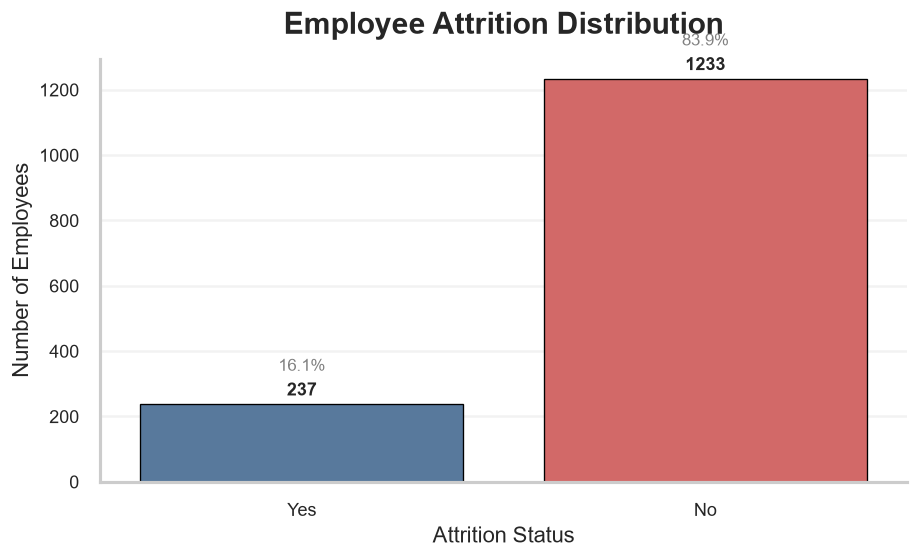

In [17]:
# ==========================================================
# Target Variable Distribution
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Attrition",
    hue="Attrition",
    palette=[PRIMARY, DANGER],
    legend=False,
    edgecolor="black",
    linewidth=0.8,
    ax=ax
)

# Value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=11,
        fontweight="bold",
        padding=3
    )

# Percentage labels
total = len(df)

for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"

    ax.annotate(
        percentage,
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        color="gray",
        xytext=(0, 18),
        textcoords="offset points"
    )

ax.set_title(
    "Employee Attrition Distribution",
    pad=15
)

ax.set_xlabel("Attrition Status")
ax.set_ylabel("Number of Employees")

sns.despine()

plt.tight_layout()
plt.show()

# 5. Feature Cardinality Analysis

We analyze unique categories per feature to identify high-cardinality columns.

### Feature Unique Counts
We count unique values for each feature and plot them in a bar chart to visualize cardinality.

In [18]:
# ==========================================================
# Unique Values Per Feature
# ==========================================================

unique_counts = (
    df.nunique()
      .sort_values(ascending=False)
      .rename("Unique Values")
      .to_frame()
)

display(unique_counts)

,Unique Values
EmployeeNumber,1470
MonthlyRate,1427
MonthlyIncome,1349
DailyRate,886
HourlyRate,71
Age,43
TotalWorkingYears,40
YearsAtCompany,37
DistanceFromHome,29
YearsInCurrentRole,19


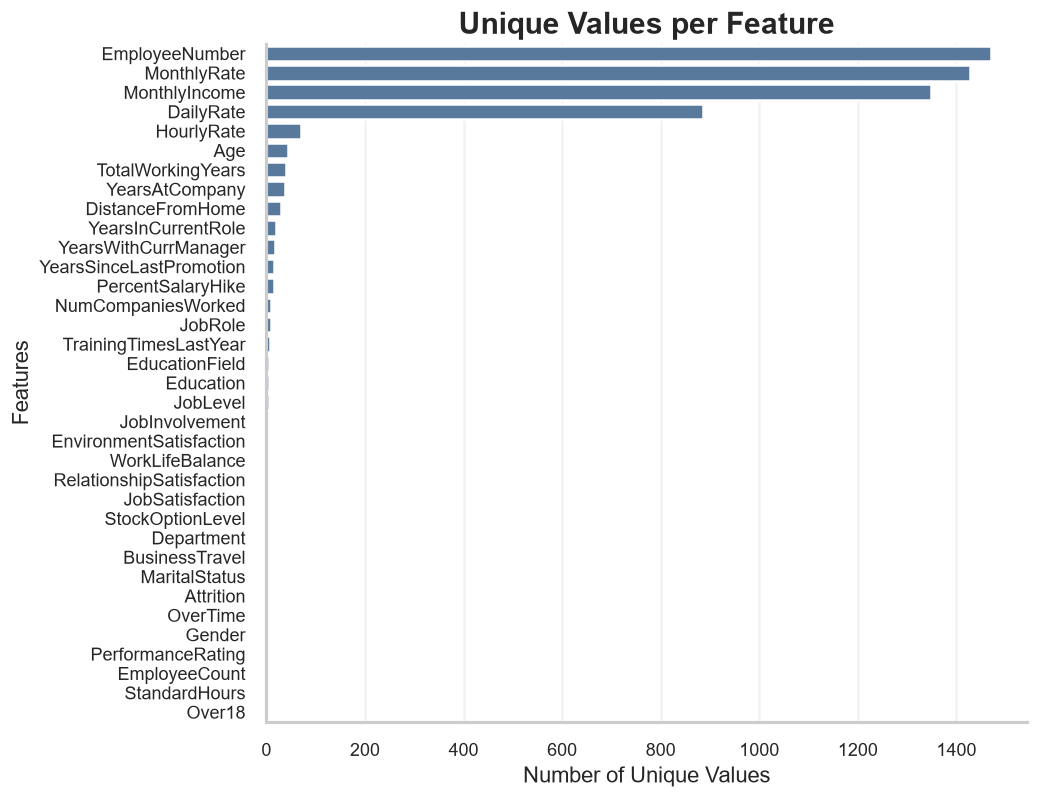

In [23]:
# ==========================================================
# Feature Cardinality
# ==========================================================

fig, ax = plt.subplots(figsize=(9, 7))

sns.barplot(
    x=unique_counts["Unique Values"],
    y=unique_counts.index,
    color=PRIMARY,
    ax=ax
)

ax.set_title("Unique Values per Feature")
ax.set_xlabel("Number of Unique Values")
ax.set_ylabel("Features")

sns.despine()

plt.tight_layout()
plt.show()

### Cardinality Summary
Most categorical variables contain only a few unique categories, making them suitable for one-hot encoding. Continuous numerical features such as `MonthlyIncome` and `DailyRate` exhibit high cardinality and will remain numerical during preprocessing.

# 6. Class Imbalance and Data Consistency Check

We verify class proportions and run logical sanity checks.

### Class Proportions
We review the relative frequencies of each class within our target `Attrition`.

In [24]:
# ==========================================================
# Class Distribution
# ==========================================================

class_distribution = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(class_distribution)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

### Logical Sanity Checks
We run checks to confirm that numeric values fall within valid logical ranges (e.g., non-negative ages, non-negative income, ages under 100).

In [25]:
# ==========================================================
# Sanity Checks
# ==========================================================

print("Negative Monthly Income:",
      (df["MonthlyIncome"] < 0).sum())

print("Negative Age:",
      (df["Age"] < 0).sum())

print("Age greater than 100:",
      (df["Age"] > 100).sum())

print("Negative Years At Company:",
      (df["YearsAtCompany"] < 0).sum())

Negative Monthly Income: 0
Negative Age: 0
Age greater than 100: 0
Negative Years At Company: 0


# 7. Data Quality Audit Summary

### Key Findings

- **Dimensions**: The dataset contains **1470 employee records** and **35 features**.
- **Completeness**: No missing values were detected.
- **Uniqueness**: No duplicate records were found.
- **Variance**: Zero-variance constant columns were identified (`EmployeeCount`, `StandardHours`, `Over18`). These do not add value and will be removed during feature engineering.
- **Data Types**: Inferred types match structural data fields.
- **Consistency**: Logical sanity checks confirmed all numeric entries are valid and within expected boundaries.
- **Class Imbalance**: The target variable `Attrition` is imbalanced, with **16.12%** of employees leaving and **83.88%** remaining.

### Conclusion

The dataset is clean and logically consistent. Aside from removing zero-variance features during preprocessing, the dataset is suitable for Exploratory Data Analysis.